# BPJS Kesehatan Fraud Detection: Exploratory Data Analysis (EDA)
This notebook analyzes the cleaned dataset used for the MAMAB (Multi-Agent Multi-Armed Bandit) simulation.

### Data Dictionary
Below is the explanation of the features present in the dataset after the cleaning and one-hot encoding process:

*   **`kdkc`**: BPJS Branch Office Area Code (Used to simulate regional agents in Federated Learning).
*   **`umur`**: Patient's age.
*   **`los`**: Length of Stay (Days hospitalized).
*   **`severitylevel`**: Level of disease severity/urgency (0 to 3).
*   **`utility_score`**: The financial proxy weight assigned based on severity (1, 3, 8).
*   **`is_male`**: Patient's gender (1 = Male, 0 = Female, -1 = Unknown).
*   **`label`**: Ground truth fraud flag (1 = Fraud, 0 = Clean).
*   **`jnspelsep_2`**: Level of service (1 = Outpatient (rawat jalan)).
*   **`dx2_*`**: Secondary Diagnosis groupings based on ICD-10 chapters (Binary: 0 or 1).
*   **`proc_*`**: Medical Procedure groupings based on INA-CBG chapters (Binary: 0 or 1).
*   **`typeppk_*`**: Hospital Type code (e.g., A, B, C, D) one-hot encoded (Binary: 0 or 1).
*   **`cmg_*`**: Case Mix Group classifications one-hot encoded (Binary: 0 or 1).
*   **`diagprimer_*`**: Primary Diagnosis based on ICD-10 chapters one-hot encoded (Binary: 0 or 1).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the dataset
file_path = r"Data/fraud_detection_cleaned2.csv"
print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)

print("\nData loaded successfully!")

Loading data from: Data/fraud_detection_cleaned2.csv

Data loaded successfully!


In [2]:
# 1. General Overview
total_rows = len(df)
total_cols = len(df.columns)
total_branches = df['kdkc'].nunique()

print("="*40)
print("1. DATASET OVERVIEW")
print("="*40)
print(f"Total Claims (Rows): {total_rows:,}")
print(f"Total Features (Columns): {total_cols:,}")
print(f"Total BPJS Branches (kdkc): {total_branches:,}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

1. DATASET OVERVIEW
Total Claims (Rows): 200,217
Total Features (Columns): 115
Total BPJS Branches (kdkc): 126
Memory Usage: 175.67 MB


2. FRAUD VS CLEAN DISTRIBUTION
Fraud Claims: 100,255 (50.07%)
Clean Claims: 99,962 (49.93%)


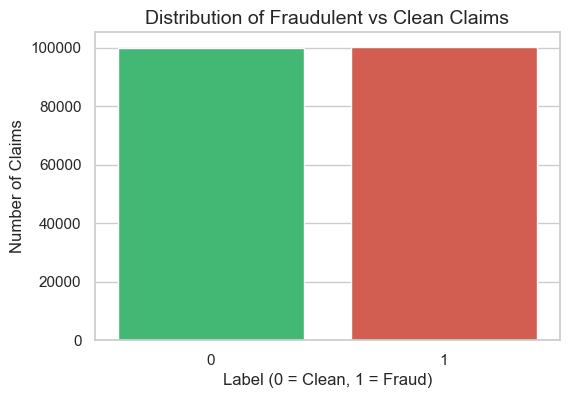

In [3]:
# 2. Target Variable (Label) Distribution
print("="*40)
print("2. FRAUD VS CLEAN DISTRIBUTION")
print("="*40)

fraud_counts = df['label'].value_counts()
fraud_pct = df['label'].value_counts(normalize=True) * 100

for label, count in fraud_counts.items():
    status = "Fraud" if label == 1 else "Clean"
    print(f"{status} Claims: {count:,} ({fraud_pct[label]:.2f}%)")

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])
plt.title("Distribution of Fraudulent vs Clean Claims", fontsize=14)
plt.xlabel("Label (0 = Clean, 1 = Fraud)")
plt.ylabel("Number of Claims")
plt.show()

3. SEVERITY LEVEL & UTILITY SCORE
Claims by Severity Level:
 - Level 0: 134,103 claims
 - Level 1: 48,487 claims
 - Level 2: 12,471 claims
 - Level 3: 5,156 claims

Fraud Distribution by Severity Level:
               % Clean  % Fraud
severitylevel                  
0                48.06    51.94
1                56.48    43.52
2                48.58    51.42
3                40.15    59.85


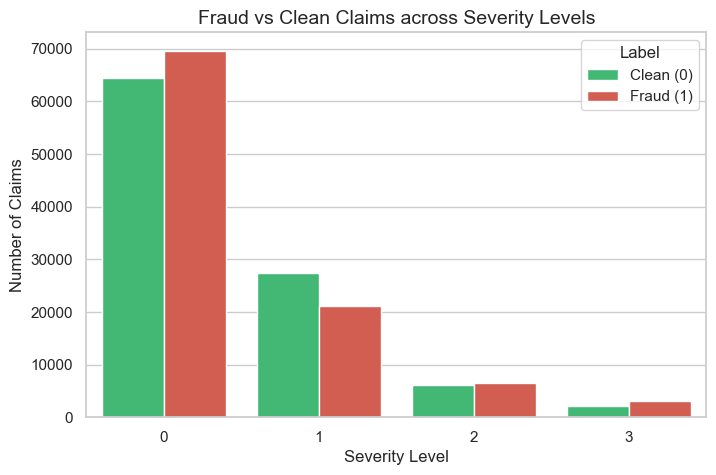

In [4]:
# 3. Severity Level and Utility Analysis
print("="*40)
print("3. SEVERITY LEVEL & UTILITY SCORE")
print("="*40)

severity_counts = df['severitylevel'].value_counts().sort_index()
print("Claims by Severity Level:")
for sev, count in severity_counts.items():
    print(f" - Level {sev}: {count:,} claims")

# Crosstab to show Fraud rate per Severity Level
print("\nFraud Distribution by Severity Level:")
fraud_by_severity = pd.crosstab(df['severitylevel'], df['label'], normalize='index') * 100
fraud_by_severity.columns = ['% Clean', '% Fraud']
print(fraud_by_severity.round(2))

# Visualize Fraud by Severity
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='severitylevel', hue='label', palette=['#2ecc71', '#e74c3c'])
plt.title("Fraud vs Clean Claims across Severity Levels", fontsize=14)
plt.xlabel("Severity Level")
plt.ylabel("Number of Claims")
plt.legend(title="Label", labels=['Clean (0)', 'Fraud (1)'])
plt.show()

In [5]:
# 4. Patient Demographics & Hospital Metrics
print("="*40)
print("4. PATIENT & HOSPITAL METRICS")
print("="*40)

# Gender
genders = df['is_male'].value_counts()
print(f"Gender Distribution:")
print(f" - Male (1): {genders.get(1, 0):,}")
print(f" - Female (0): {genders.get(0, 0):,}")
print(f" - Unknown (-1): {genders.get(-1, 0):,}\n")

# Age and Length of Stay Stats
print("Age ('umur') Statistics:")
print(df['umur'].describe()[['mean', 'min', 'max', '50%']].to_string())

print("\nLength of Stay ('los') Statistics:")
print(df['los'].describe()[['mean', 'min', 'max', '50%']].to_string())

# Service Type
outpatients = df['jnspelsep_2'].sum()
inpatients = len(df) - outpatients
print(f"\nService Type:")
print(f" - Inpatient (Hospitalized): {inpatients:,}")
print(f" - Outpatient (Clinic Visit): {outpatients:,}")

4. PATIENT & HOSPITAL METRICS
Gender Distribution:
 - Male (1): 92,843
 - Female (0): 107,374
 - Unknown (-1): 0

Age ('umur') Statistics:
mean     36.850602
min       0.000000
max     109.000000
50%      39.000000

Length of Stay ('los') Statistics:
mean      1.303356
min       0.000000
max     592.000000
50%       0.000000

Service Type:
 - Inpatient (Hospitalized): 66,116
 - Outpatient (Clinic Visit): 134,101


In [6]:
# 5. Top BPJS Branches Analysis
print("="*40)
print("5. TOP 5 BPJS BRANCHES BY CLAIM VOLUME")
print("="*40)

top_branches = df['kdkc'].value_counts().head(5)
for branch, count in top_branches.items():
    print(f"Branch Code {branch}: {count:,} claims")

# Calculate fraud rate for the top 5 branches
print("\nFraud Rate in Top 5 Branches:")
for branch in top_branches.index:
    branch_data = df[df['kdkc'] == branch]
    fraud_rate = branch_data['label'].mean() * 100
    print(f" - Branch {branch}: {fraud_rate:.2f}% Fraud")

5. TOP 5 BPJS BRANCHES BY CLAIM VOLUME
Branch Code 601: 4,472 claims
Branch Code 1301: 4,393 claims
Branch Code 1108: 4,369 claims
Branch Code 903: 4,115 claims
Branch Code 1308: 3,963 claims

Fraud Rate in Top 5 Branches:
 - Branch 601: 59.66% Fraud
 - Branch 1301: 49.74% Fraud
 - Branch 1108: 47.95% Fraud
 - Branch 903: 38.44% Fraud
 - Branch 1308: 46.68% Fraud


In [7]:
# 6. Identifying Top Diagnoses
print("="*40)
print("6. TOP PRIMARY DIAGNOSIS CATEGORIES")
print("="*40)

# Find all columns related to primary diagnosis
diag_cols = [col for col in df.columns if col.startswith('diagprimer_')]

# Sum them up to see which are the most common
top_diagnoses = df[diag_cols].sum().sort_values(ascending=False).head(5)

for diag, count in top_diagnoses.items():
    # Clean up the string for printing
    clean_name = diag.replace('diagprimer_', '').upper()
    print(f"ICD-10 Chapter {clean_name}: {count:,} claims")

6. TOP PRIMARY DIAGNOSIS CATEGORIES
ICD-10 Chapter R00_R99: 10,205 claims
ICD-10 Chapter G00_G99: 10,175 claims
ICD-10 Chapter Z00_Z99: 10,089 claims
ICD-10 Chapter M00_M99: 10,086 claims
ICD-10 Chapter O00_O99: 10,039 claims
